# 02 — Numerical validation: benchmarks, convergence and production accuracy

**Objective.** Verify the production solver (cell-centred finite volumes, central advective fluxes, exact
Danckwerts inlet flux, Crank–Nicolson time stepping) against exact solutions, and measure — not assume —
its spatial and temporal orders of accuracy.

| Benchmark | Physics | Reference solution | Tests |
|---|---|---|---|
| A | pure advection, $D=k=0$ | translated Gaussian (exact cell averages) | transport direction and speed |
| B | pure dispersion, $u=k=0$ (closed walls) | method of images | spreading $\sigma^2(t)-\sigma^2(0)=2Dt$, mass conservation |
| C | pure reaction | $C_0e^{-kt}$ | temporal order of CN / BE / FE |
| D | advection–dispersion–reaction | infinite-domain Gaussian (boundary residual quantified) | coupled transport |
| E | steady ADR, Danckwerts | Wehner–Wilhelm profile | boundary conditions, spatial order |
| F | pulse response, Danckwerts | transfer-function moments | transient inlet/outlet conditions |
| MMS | all terms + source | manufactured solution | separate spatial and temporal orders |

Errors are measured against **exact cell averages** in the discrete norms
$\|e\|_1=h\sum|e_j|$, $\|e\|_2=(h\sum e_j^2)^{1/2}$, $\|e\|_\infty=\max|e_j|$; observed orders are
$p=\log(E_{h}/E_{h/2})/\log 2$ between successive grids.

In [1]:
# --- Environment set-up (no hidden state: every notebook starts here) -------
import sys
from pathlib import Path

try:
    import pfr_uq  # installed with `pip install -e .`
except ImportError:  # fall back to the repository's src/ directory
    root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
    sys.path.insert(0, str(root / "src"))
    import pfr_uq

import numpy as np
import pandas as pd
from pfr_uq import model, solvers, metrics, uncertainty, reporting, paths

np.set_printoptions(precision=6, suppress=False)
print("pfr_uq", pfr_uq.__version__, "| numpy", np.__version__, "| repository root:", paths.ROOT.name)

pfr_uq 1.0.0 | numpy 2.5.3 | repository root: Mohamed_AIMS_Project


In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from scipy.stats import norm as normal
from pfr_uq import qoi

SUMMARY = {}
L = 1.0

def gaussian_cells(grid, t, x0, s0, u=0.0, D=0.0, k=0.0):
    """Exact cell averages of the infinite-domain Gaussian solution (unit initial mass)."""
    return model.gaussian_pulse_infinite_cell_average(grid.faces, t, x0, s0, u, D, k)

def refinement_table(Ns, errors_fn, label):
    """Run errors_fn(N) -> dict of norms for each N and append observed orders."""
    rows = []
    for N in Ns:
        e = errors_fn(N)
        rows.append({"case": label, "N": N, "h": L / N, **e})
    df = pd.DataFrame(rows)
    for key in [c for c in df.columns if c in ("L1", "L2", "Linf", "err")]:
        p = np.r_[np.nan, metrics.observed_orders(df["h"].values, df[key].values)]
        df[f"p_{key}"] = p
    return df

## Benchmark A — pure advection (transport direction and speed)

$u=0.1$ m s$^{-1}$, $D=k=0$, Gaussian initial pulse ($x_0=0.25$ m, $s_0=0.04$ m, unit mass), $C_\mathrm{in}=0$,
$t_\mathrm{end}=4$ s, Courant number $\beta=u\Delta t/h=0.4$. With $D=0$ the Danckwerts inlet reduces to $C(0,t)=C_\mathrm{in}$.
We compare central and first-order upwind advective fluxes (both with Crank–Nicolson).

In [3]:
uA, x0A, s0A, TA = 0.1, 0.25, 0.04, 4.0

def run_A(N, adv):
    grid = solvers.Grid(L, N)
    dt = 0.4 * grid.h / uA
    op = solvers.FVOperator(uA, 0.0, 0.0, L, N, advection=adv)
    C0 = gaussian_cells(grid, 0.0, x0A, s0A)
    res = solvers.integrate(op, C0, TA, dt, inlet=0.0, save_times=(0.0, TA))
    return grid, res, C0

rows = []
for adv in ("central", "upwind"):
    grid, res, C0 = run_A(400, adv)
    C = res.snapshots[TA][0]
    exact = gaussian_cells(grid, TA, x0A, s0A, u=uA)
    centroid = lambda c: np.sum(grid.centers * c) / np.sum(c)
    speed = (centroid(C) - centroid(C0)) / TA
    rows.append({"scheme": adv, "N": 400, **metrics.error_norms(C, exact, grid.h), "measured speed [m/s]": speed,
                 "peak ratio num/exact": C.max() / exact.max(), "min C": res.min_value,
                 "mass-balance residual": res.mass_balance_residual})
    if adv == "central":
        profiles_A = pd.DataFrame({"x": grid.centers, "initial": C0, "exact": exact, "central": C})
    else:
        profiles_A["upwind"] = C
benchA = pd.DataFrame(rows)
print(benchA.to_string(index=False))
profiles_A.to_csv(paths.DATA / "benchA_profiles.csv", index=False)
convA = pd.concat([
    refinement_table([100, 200, 400, 800, 1600], lambda N, a=adv: metrics.error_norms(
        run_A(N, a)[1].snapshots[TA][0], gaussian_cells(solvers.Grid(L, N), TA, x0A, s0A, u=uA), L / N), f"A-{adv}")
    for adv in ("central", "upwind")])
print(convA.round(4).to_string(index=False))
SUMMARY["A"] = {"table": benchA.to_dict(orient="records"), "convergence": convA.to_dict(orient="records")}

 scheme   N       L1       L2     Linf  measured speed [m/s]  peak ratio num/exact         min C  mass-balance residual
central 400 0.010601 0.025519 0.097472                   0.1              1.000289 -9.711863e-09           5.684342e-16
 upwind 400 0.233733 0.522323 2.147589                   0.1              0.784923  0.000000e+00           4.404762e-16


     case    N      h     L1     L2   Linf   p_L1   p_L2  p_Linf
A-central  100 0.0100 0.1657 0.3836 1.5135    NaN    NaN     NaN
A-central  200 0.0050 0.0421 0.1013 0.3962 1.9758 1.9211  1.9337
A-central  400 0.0025 0.0106 0.0255 0.0975 1.9905 1.9888  2.0231
A-central  800 0.0012 0.0027 0.0064 0.0242 1.9984 1.9979  2.0077
A-central 1600 0.0006 0.0007 0.0016 0.0061 1.9995 1.9995  2.0018
 A-upwind  100 0.0100 0.5851 1.1872 4.5728    NaN    NaN     NaN
 A-upwind  200 0.0050 0.3866 0.8292 3.3119 0.5980 0.5178  0.4654
 A-upwind  400 0.0025 0.2337 0.5223 2.1476 0.7258 0.6668  0.6249
 A-upwind  800 0.0012 0.1314 0.3017 1.2676 0.8312 0.7919  0.7606
 A-upwind 1600 0.0006 0.0702 0.1639 0.6983 0.9036 0.8806  0.8602


The centroid moves downstream at the imposed speed (relative error well below 1%). Central fluxes converge at
second order; first-order upwind converges at first order and visibly smears the pulse through its numerical
dispersion $uh/2$. Central fluxes without physical dispersion produce small dispersive undershoots (negative
minimum), which disappear once the cell Péclet number $uh/D$ is below 2 (benchmarks D–F).

## Benchmark B — pure dispersion in a closed vessel

$u=0$ makes both Danckwerts conditions no-flux conditions, $D=10^{-3}$ m$^2$ s$^{-1}$, Gaussian initial pulse at
$x_0=0.5$ m ($s_0=0.05$ m), $t_\mathrm{end}=10$ s. The exact finite-domain solution is the method-of-images sum.

In [4]:
DB, x0B, s0B, TB = 1e-3, 0.5, 0.05, 10.0

def run_B(N, dt=None):
    grid = solvers.Grid(L, N)
    dt = dt if dt is not None else 0.05 * 200 / N
    op = solvers.FVOperator(0.0, DB, 0.0, L, N)
    C0 = metrics.cell_average(lambda xv: model.gaussian_pulse_noflux_images(xv, 0.0, x0B, s0B, DB, L), grid.faces)
    res = solvers.integrate(op, C0, TB, dt, save_times=(0.0, TB))
    exact = metrics.cell_average(lambda xv: model.gaussian_pulse_noflux_images(xv, TB, x0B, s0B, DB, L), grid.faces)
    return grid, res, C0, exact

grid, res, C0, exact = run_B(400)
C = res.snapshots[TB][0]
xc = grid.centers
var_num = lambda c: np.sum((xc - np.sum(xc * c) / np.sum(c)) ** 2 * c) / np.sum(c)
var_gain_num = var_num(C) - var_num(C0)
var_gain_exact = var_num(exact) - var_num(C0)
mass_drift = abs(res.mass[-1, 0] - res.mass[0, 0])
benchB = {"N": 400, **metrics.error_norms(C, exact, grid.h), "variance gain numerical": var_gain_num,
          "variance gain exact (images)": var_gain_exact, "2 D t": 2 * DB * TB, "mass drift": mass_drift,
          "peak ratio C_max(t)/C_max(0)": C.max() / C0.max(), "sqrt(s0^2/(s0^2+2Dt))": np.sqrt(s0B**2 / (s0B**2 + 2 * DB * TB))}
for kk, vv in benchB.items():
    print(f"{kk:35s} {vv:.6g}")
pd.DataFrame({"x": xc, "initial": C0, "exact": exact, "numerical": C}).to_csv(paths.DATA / "benchB_profiles.csv", index=False)
convB = refinement_table([50, 100, 200, 400, 800], lambda N: (lambda r: metrics.error_norms(r[1].snapshots[TB][0], r[3], L / N))(run_B(N)), "B")
print(convB.round(4).to_string(index=False))
SUMMARY["B"] = {"table": benchB, "convergence": convB.to_dict(orient="records")}

N                                   400
L1                                  2.82028e-05
L2                                  3.55831e-05
Linf                                8.0255e-05
variance gain numerical             0.0199326
variance gain exact (images)        0.0199327
2 D t                               0.02
mass drift                          0
peak ratio C_max(t)/C_max(0)        0.333467
sqrt(s0^2/(s0^2+2Dt))               0.333333
case   N      h     L1     L2   Linf   p_L1   p_L2  p_Linf
   B  50 0.0200 0.0018 0.0023 0.0051    NaN    NaN     NaN
   B 100 0.0100 0.0005 0.0006 0.0013 1.9943 2.0023  1.9933
   B 200 0.0050 0.0001 0.0001 0.0003 2.0010 2.0006  1.9983
   B 400 0.0025 0.0000 0.0000 0.0001 2.0000 2.0001  1.9996
   B 800 0.0012 0.0000 0.0000 0.0000 2.0000 2.0000  1.9999


Mass is conserved to round-off, the variance grows as $2Dt$ (the walls are $>4$ standard deviations away, so
the images change the variance only marginally), and the peak decays as $(s_0^2/(s_0^2+2Dt))^{1/2}$ — the
finite-width analogue of the $t^{-1/2}$ law of the point-source kernel.

## Benchmark C — first-order reaction (temporal order)

$u=D=0$, uniform $C_0=1$ mol m$^{-3}$, $k=0.1$ s$^{-1}$, $t_\mathrm{end}=20$ s; exact $C=e^{-kt}$.
Forward Euler is included for comparison (it is stable here because $\kappa=k\Delta t\le 2$).

In [5]:
kC, TC = 0.1, 20.0
rows = []
for scheme, th in (("CN", 0.5), ("BE", 1.0), ("FE", 0.0)):
    for n in (10, 20, 40, 80, 160, 320, 640):
        dt = TC / n
        op = solvers.FVOperator(0.0, 0.0, kC, L, 4)
        res = solvers.integrate(op, 1.0, TC, dt, theta=th)
        rows.append({"scheme": scheme, "n_steps": n, "dt": dt, "err": abs(res.final[0, 0] - np.exp(-kC * TC))})
convC = pd.DataFrame(rows)
convC["p_err"] = convC.groupby("scheme")["err"].transform(lambda e: np.r_[np.nan, np.log2(e.values[:-1] / e.values[1:])])
print(convC.to_string(index=False))
SUMMARY["C"] = convC.to_dict(orient="records")

scheme  n_steps      dt          err    p_err
    CN       10 2.00000 9.046505e-04      NaN
    CN       20 1.00000 2.257093e-04 2.002895
    CN       40 0.50000 5.639910e-05 2.000722
    CN       80 0.25000 1.409801e-05 2.000180
    CN      160 0.12500 3.524393e-06 2.000045
    CN      320 0.06250 8.810914e-07 2.000011
    CN      640 0.03125 2.202724e-07 2.000003
    BE       10 2.00000 2.617030e-02      NaN
    BE       20 1.00000 1.330834e-02 0.975599
    BE       40 0.50000 6.710399e-03 0.987861
    BE       80 0.25000 3.369286e-03 0.993956
    BE      160 0.12500 1.688167e-03 0.996986
    BE      320 0.06250 8.449644e-04 0.998495
    BE      640 0.03125 4.227025e-04 0.999248
    FE       10 2.00000 2.796110e-02      NaN
    FE       20 1.00000 1.375863e-02 1.023084
    FE       40 0.50000 6.823127e-03 1.011832
    FE       80 0.25000 3.397478e-03 1.005969
    FE      160 0.12500 1.695215e-03 1.002996
    FE      320 0.06250 8.467266e-04 1.001500
    FE      640 0.03125 4.231430e-

## Benchmark D — advection–dispersion–reaction (infinite-domain Gaussian)

$u=0.1$ m s$^{-1}$, $D=10^{-4}$ m$^2$ s$^{-1}$, $k=0.05$ s$^{-1}$, Gaussian at $x_0=0.2$ m ($s_0=0.03$ m), $t_\mathrm{end}=5$ s.
The infinite-domain solution is a valid reference only if it satisfies the finite-domain boundary conditions to
within the errors measured; we evaluate both Danckwerts residuals of the exact solution over $[0,t_\mathrm{end}]$.

In [6]:
uD, DD, kD, x0D, s0D, TD = 0.1, 1e-4, 0.05, 0.2, 0.03, 5.0
# Boundary residuals of the infinite-domain solution
tt = np.linspace(0, TD, 501)
Cx = lambda xv, t: -(xv - x0D - uD * t) / (s0D**2 + 2 * DD * t) * model.gaussian_pulse_infinite(xv, t, x0D, s0D, uD, DD, kD)
inlet_resid = np.max(np.abs(uD * model.gaussian_pulse_infinite(0.0, tt, x0D, s0D, uD, DD, kD) - DD * Cx(0.0, tt)))
outlet_resid = np.max(np.abs(Cx(L, tt)))
print(f"max |u C - D C_x| at x=0: {inlet_resid:.2e} mol m^-2 s^-1;  max |C_x| at x=L: {outlet_resid:.2e} mol m^-4")

def run_D(N):
    grid = solvers.Grid(L, N)
    dt = 0.25 * grid.h / uD
    op = solvers.FVOperator(uD, DD, kD, L, N)
    res = solvers.integrate(op, gaussian_cells(grid, 0.0, x0D, s0D), TD, dt, save_times=(TD,))
    return grid, res

grid, res = run_D(800)
CD = res.snapshots[TD][0]
exD = gaussian_cells(grid, TD, x0D, s0D, uD, DD, kD)
benchD = {"N": 800, "cell Peclet uh/D": uD * grid.h / DD, **metrics.error_norms(CD, exD, grid.h),
          "mass numerical": res.mass[-1, 0], "mass exact exp(-kt)": np.exp(-kD * TD), "min C": res.min_value,
          "inlet residual of reference": inlet_resid, "outlet residual of reference": outlet_resid}
for kk, vv in benchD.items():
    print(f"{kk:32s} {vv:.6g}")
pd.DataFrame({"x": grid.centers, "exact": exD, "numerical": CD, "initial": gaussian_cells(grid, 0.0, x0D, s0D)}).to_csv(
    paths.DATA / "benchD_profiles.csv", index=False)
convD = refinement_table([100, 200, 400, 800, 1600], lambda N: metrics.error_norms(
    run_D(N)[1].snapshots[TD][0], gaussian_cells(solvers.Grid(L, N), TD, x0D, s0D, uD, DD, kD), L / N), "D")
print(convD.round(4).to_string(index=False))
SUMMARY["D"] = {"table": benchD, "convergence": convD.to_dict(orient="records")}

max |u C - D C_x| at x=0: 2.31e-10 mol m^-2 s^-1;  max |C_x| at x=L: 5.83e-08 mol m^-4
N                                800
cell Peclet uh/D                 1.25
L1                               0.00190652
L2                               0.00439818
Linf                             0.0159947
mass numerical                   0.778801
mass exact exp(-kt)              0.778801
min C                            0
inlet residual of reference      2.31023e-10
outlet residual of reference     5.82647e-08


case    N      h     L1     L2   Linf   p_L1   p_L2  p_Linf
   D  100 0.0100 0.1200 0.2697 1.0341    NaN    NaN     NaN
   D  200 0.0050 0.0304 0.0701 0.2610 1.9811 1.9448  1.9864
   D  400 0.0025 0.0076 0.0176 0.0643 1.9950 1.9945  2.0213
   D  800 0.0012 0.0019 0.0044 0.0160 1.9997 1.9992  2.0070
   D 1600 0.0006 0.0005 0.0011 0.0040 1.9998 1.9998  2.0025


## Benchmark E — steady advection–dispersion–reaction with Danckwerts conditions

The direct steady solve $A\mathbf C=-\mathbf g$ is compared with the exact profile for three regimes; one case is
also obtained by time marching to steady state.

In [7]:
casesE = [("Pe=10, Da=1", 0.1, 0.01, 0.1), ("Pe=100, Da=2", 0.1, 1e-3, 0.2), ("Pe=1000, Da=1", 0.1, 1e-4, 0.1)]
rowsE, profilesE = [], {}
for label, uu, DDe, kk in casesE:
    Pe, Da = uu * L / DDe, kk * L / uu
    Ns = [50, 100, 200, 400, 800, 1600] if Pe < 500 else [500, 1000, 2000, 4000, 8000]
    for N in Ns:
        op = solvers.FVOperator(uu, DDe, kk, L, N)
        Cs = solvers.solve_steady(op, 1.0)[0]
        grid = op.grid
        exact = metrics.cell_average(lambda xv: model.danckwerts_profile(xv / L, Pe, Da), grid.faces)
        rowsE.append({"case": label, "N": N, "h": grid.h, "cell Peclet": uu * grid.h / DDe,
                      **metrics.error_norms(Cs, exact, grid.h),
                      "outlet error": abs(Cs[-1] - model.danckwerts_outlet_ratio(Pe, Da))})
        if N == Ns[2]:
            profilesE[label] = (grid.centers, Cs, exact)
convE = pd.DataFrame(rowsE)
for key in ("L2", "Linf", "outlet error"):
    convE[f"p_{key}"] = convE.groupby("case")[key].transform(lambda e: np.r_[np.nan, np.log2(e.values[:-1] / e.values[1:])])
print(convE.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
# time marching to steady state (baseline)
op = solvers.FVOperator(0.1, 0.01, 0.1, L, 200)
march = solvers.integrate(op, 0.0, 300.0, 0.1, inlet=1.0)
diff_march = np.max(np.abs(march.final[0] - solvers.solve_steady(op, 1.0)[0]))
print(f"time-marched (t=300 s) vs direct steady solve, max difference: {diff_march:.2e}")
rowsP = []
for label, (xc_, Cs, ex) in profilesE.items():
    rowsP.append(pd.DataFrame({"case": label, "x": xc_, "numerical": Cs, "exact": ex}))
pd.concat(rowsP).to_csv(paths.DATA / "benchE_profiles.csv", index=False)
SUMMARY["E"] = {"convergence": convE.to_dict(orient="records"), "march_vs_direct": diff_march}

         case    N         h  cell Peclet        L1        L2      Linf  outlet error      p_L2    p_Linf  p_outlet error
  Pe=10, Da=1   50 2.000e-02    2.000e-01 4.657e-05 6.328e-05 2.056e-04     4.657e-05       NaN       NaN             NaN
  Pe=10, Da=1  100 1.000e-02    1.000e-01 1.164e-05 1.582e-05 5.295e-05     1.164e-05 2.000e+00 1.957e+00       2.000e+00
  Pe=10, Da=1  200 5.000e-03    5.000e-02 2.911e-06 3.956e-06 1.344e-05     2.911e-06 2.000e+00 1.978e+00       2.000e+00
  Pe=10, Da=1  400 2.500e-03    2.500e-02 7.277e-07 9.889e-07 3.385e-06     7.277e-07 2.000e+00 1.989e+00       2.000e+00
  Pe=10, Da=1  800 1.250e-03    1.250e-02 1.819e-07 2.472e-07 8.494e-07     1.819e-07 2.000e+00 1.995e+00       2.000e+00
  Pe=10, Da=1 1600 6.250e-04    6.250e-03 4.548e-08 6.180e-08 2.127e-07     4.548e-08 2.000e+00 1.997e+00       2.000e+00
 Pe=100, Da=2   50 2.000e-02    2.000e+00 7.977e-05 1.767e-04 1.099e-03     1.208e-04       NaN       NaN             NaN
 Pe=100, Da=2  100 1.000

## Benchmark F — transient Danckwerts conditions via outlet moments

For a linear, time-invariant reactor the exit response to any feed $C_\mathrm{in}(t)$ is the convolution with the
impulse response, whose Laplace transform is $G(s)=\varphi(1;\mathrm{Pe},\mathrm{Da}+s\tau)$, the steady outlet ratio
evaluated at $\mathrm{Da}+s\tau$ ($\tau=L/u$). Hence, exactly,
$$\frac{\int C_\mathrm{out}\,dt}{\int C_\mathrm{in}\,dt}=G(0),\quad
\bar t_\mathrm{out}-\bar t_\mathrm{in}=-\tau\,\partial_{\mathrm{Da}}\ln G,\quad
\sigma^2_\mathrm{out}-\sigma^2_\mathrm{in}=\tau^2\,\partial^2_{\mathrm{Da}}\ln G.$$
For $\mathrm{Da}=0$ these reduce to the closed-vessel results $\bar t=\tau$ and
$\sigma^2/\tau^2=2/\mathrm{Pe}-2(1-e^{-\mathrm{Pe}})/\mathrm{Pe}^2$. Derivatives of $\ln G$ are taken by central
differences of the closed form (step $10^{-3}$; error $<10^{-6}$ relative).

In [8]:
def lnG(Pe, Da):
    return np.log(model.danckwerts_outlet_ratio(Pe, Da))

def moment_shifts(Pe, Da, tau, d=1e-3):
    # one-sided at Da = 0 is avoided: lnG is analytic in Da for Da > -Pe/4, so central differences are valid
    g1 = (lnG(Pe, Da + d) - lnG(Pe, Da - d)) / (2 * d)
    g2 = (lnG(Pe, Da + d) - 2 * lnG(Pe, Da) + lnG(Pe, Da - d)) / d**2
    return -tau * g1, tau**2 * g2

uF, tcF, wF = 0.1, 5.0, 1.0
tauF = L / uF
rowsF = []
for Pe in (2.0, 10.0, 50.0):
    for Da in (0.0, 1.0):
        DF, kF = uF * L / Pe, Da * uF / L
        N = 400
        op = solvers.FVOperator(uF, DF, kF, L, N)
        res = solvers.integrate(op, 0.0, 400.0, 0.05, inlet=lambda t: model.gaussian_inlet_pulse(t, 1.0, tcF, wF))
        m0o, mo, vo = metrics.curve_moments(res.t, res.outlet[:, 0])
        m0i, mi, vi = metrics.curve_moments(res.t, res.inlet[:, 0])
        dmean, dvar = moment_shifts(Pe, Da, tauF)
        rowsF.append({"Pe": Pe, "Da": Da, "yield num": m0o / m0i, "yield exact": model.danckwerts_outlet_ratio(Pe, Da),
                      "mean shift num [s]": mo - mi, "mean shift exact [s]": dmean,
                      "var shift num [s^2]": vo - vi, "var shift exact [s^2]": dvar,
                      "closed-vessel var (Da=0) [s^2]": tauF**2 * model.closed_vessel_rtd_variance(Pe),
                      "C_out(T)": res.outlet[-1, 0], "mass resid": res.mass_balance_residual})
benchF = pd.DataFrame(rowsF)
benchF["rel err yield"] = abs(benchF["yield num"] / benchF["yield exact"] - 1)
benchF["rel err mean"] = abs(benchF["mean shift num [s]"] / benchF["mean shift exact [s]"] - 1)
benchF["rel err var"] = abs(benchF["var shift num [s^2]"] / benchF["var shift exact [s^2]"] - 1)
print(benchF.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
benchF.to_csv(paths.DATA / "benchF_moments.csv", index=False)
SUMMARY["F"] = benchF.to_dict(orient="records")

 Pe  Da  yield num  yield exact  mean shift num [s]  mean shift exact [s]  var shift num [s^2]  var shift exact [s^2]  closed-vessel var (Da=0) [s^2]     C_out(T)  mass resid  rel err yield  rel err mean  rel err var
  2   0          1            1                  10                    10               56.767                56.7668                         56.7668  3.01478e-24 3.48441e-15    2.96696e-12   1.35241e-07  4.00067e-06
  2   1   0.447399     0.447399             6.66665               6.66667              19.7828                19.7827                         56.7668 -1.94236e-26 2.11494e-14    8.12944e-07   2.12249e-06  4.28339e-06
 10   0          1            1                  10                    10              18.0004                18.0001                         18.0001  1.45694e-51 2.65087e-16    9.78106e-14    1.5908e-08  1.73149e-05
 10   1   0.397268     0.397267             8.57139               8.57143              11.4033                11.4029               

## Manufactured solutions: separate spatial and temporal orders

**Spatial order (steady MMS).** $C_e(x)=0.5+(1-x/L)^2\,(1+\sin(\pi x/L))$ satisfies $C_e'(L)=0$ and has
$C_e'(0)\neq0$, so both boundary conditions are exercised. The source is $s=uC_e'-DC_e''+kC_e$ (cell-averaged)
and the feed $C_\mathrm{in}=C_e(0)-(D/u)C_e'(0)$. The steady discrete problem has no time-discretisation error.

**Temporal order (transient MMS).** $C_e(x,t)=0.5+e^{-t/5}(1-x/L)^2(1+\sin(\pi x/L))+0.2\sin(\pi t/2)\cos(\pi x/L)$.
At fixed $N=200$ the temporal error is measured against a reference computed on the *same* grid with a 64× smaller
step, which isolates it from the spatial error. A combined refinement ($\Delta t\propto h$) is compared with the exact solution.

In [9]:
xs, ts = sp.symbols("x t", real=True)
uM, DM, kM = sp.symbols("u D k", positive=True)
Ce_steady = sp.Rational(1, 2) + (1 - xs / L) ** 2 * (1 + sp.sin(sp.pi * xs / L))
Ce_trans = sp.Rational(1, 2) + sp.exp(-ts / 5) * (1 - xs / L) ** 2 * (1 + sp.sin(sp.pi * xs / L)) + sp.Rational(1, 5) * sp.sin(sp.pi * ts / 2) * sp.cos(sp.pi * xs / L)
for name, Ce in (("steady", Ce_steady), ("transient", Ce_trans)):
    assert sp.simplify(sp.diff(Ce, xs).subs(xs, L)) == 0, name
src_steady = sp.simplify(uM * sp.diff(Ce_steady, xs) - DM * sp.diff(Ce_steady, xs, 2) + kM * Ce_steady)
src_trans = sp.simplify(sp.diff(Ce_trans, ts) + uM * sp.diff(Ce_trans, xs) - DM * sp.diff(Ce_trans, xs, 2) + kM * Ce_trans)
cin_steady = sp.simplify((Ce_steady - DM / uM * sp.diff(Ce_steady, xs)).subs(xs, 0))
cin_trans = sp.simplify((Ce_trans - DM / uM * sp.diff(Ce_trans, xs)).subs(xs, 0))
print("C_in (steady MMS)   =", cin_steady)
print("C_in (transient MMS)=", cin_trans)
f_Ce_s = sp.lambdify(xs, Ce_steady, "numpy")
f_Ce_t = sp.lambdify((xs, ts), Ce_trans, "numpy")
f_src_s = sp.lambdify((xs, uM, DM, kM), src_steady, "numpy")
f_src_t = sp.lambdify((xs, ts, uM, DM, kM), src_trans, "numpy")
f_cin_s = sp.lambdify((uM, DM), cin_steady, "numpy")
f_cin_t = sp.lambdify((ts, uM, DM), cin_trans, "numpy")

C_in (steady MMS)   = (D*(2.0 - pi) + 3*u/2)/u
C_in (transient MMS)= (-D*(-2.0 + pi) + u*(2*sin(pi*t/2) + 5)*exp(t/5)/10 + u)*exp(-t/5)/u


In [10]:
mms_cases = [("Pe=10, Da=1", 0.1, 0.01, 0.1), ("Pe=200, Da=1", 0.1, 5e-4, 0.1)]
rows = []
for label, uu, DDm, kk in mms_cases:
    for adv in ("central", "upwind"):
        for N in (20, 40, 80, 160, 320, 640, 1280):
            op = solvers.FVOperator(uu, DDm, kk, L, N, advection=adv)
            g = op.grid
            src = metrics.cell_average(lambda xv: f_src_s(xv, uu, DDm, kk), g.faces)
            Cs = solvers.solve_steady(op, f_cin_s(uu, DDm), source=src)[0]
            exact = metrics.cell_average(f_Ce_s, g.faces)
            rows.append({"case": label, "advection": adv, "N": N, "h": g.h, "cell Peclet": uu * g.h / DDm,
                         **metrics.error_norms(Cs, exact, g.h)})
mms_space = pd.DataFrame(rows)
for key in ("L1", "L2", "Linf"):
    mms_space[f"p_{key}"] = mms_space.groupby(["case", "advection"])[key].transform(
        lambda e: np.r_[np.nan, np.log2(e.values[:-1] / e.values[1:])])
print(mms_space.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
mms_space.to_csv(paths.TABLES / "convergence_space_mms.csv", index=False)

        case advection    N         h  cell Peclet        L1        L2      Linf      p_L1      p_L2    p_Linf
 Pe=10, Da=1   central   20 5.000e-02    5.000e-01 1.799e-03 2.030e-03 3.867e-03       NaN       NaN       NaN
 Pe=10, Da=1   central   40 2.500e-02    2.500e-01 4.492e-04 5.076e-04 9.768e-04 2.001e+00 2.000e+00 1.985e+00
 Pe=10, Da=1   central   80 1.250e-02    1.250e-01 1.123e-04 1.269e-04 2.452e-04 2.000e+00 2.000e+00 1.994e+00
 Pe=10, Da=1   central  160 6.250e-03    6.250e-02 2.808e-05 3.172e-05 6.143e-05 2.000e+00 2.000e+00 1.997e+00
 Pe=10, Da=1   central  320 3.125e-03    3.125e-02 7.021e-06 7.931e-06 1.537e-05 2.000e+00 2.000e+00 1.999e+00
 Pe=10, Da=1   central  640 1.563e-03    1.563e-02 1.755e-06 1.983e-06 3.844e-06 2.000e+00 2.000e+00 1.999e+00
 Pe=10, Da=1   central 1280 7.813e-04    7.813e-03 4.388e-07 4.957e-07 9.613e-07 2.000e+00 2.000e+00 2.000e+00
 Pe=10, Da=1    upwind   20 5.000e-02    5.000e-01 1.778e-02 2.114e-02 3.481e-02       NaN       NaN       NaN
 

In [11]:
uT, DT_, kT, TT, NT = 0.1, 0.01, 0.1, 4.0, 200
gT = solvers.Grid(L, NT)
src_fn = lambda t: metrics.cell_average(lambda xv: f_src_t(xv, t, uT, DT_, kT), gT.faces)
cin_fn = lambda t: f_cin_t(t, uT, DT_)
C0T = metrics.cell_average(lambda xv: f_Ce_t(xv, 0.0), gT.faces)
exactT = metrics.cell_average(lambda xv: f_Ce_t(xv, TT), gT.faces)
opT = solvers.FVOperator(uT, DT_, kT, L, NT)

def run_T(n, theta, rann=0):
    return solvers.integrate(opT, C0T, TT, TT / n, inlet=cin_fn, source=src_fn, theta=theta, rannacher_steps=rann).final[0]

ref = {th: run_T(5120, th) for th in (0.5, 1.0)}
rows = []
for scheme, th, rann in (("CN", 0.5, 0), ("CN + Rannacher", 0.5, 2), ("BE", 1.0, 0)):
    for n in (5, 10, 20, 40, 80):
        C = run_T(n, th, rann)
        rows.append({"scheme": scheme, "n_steps": n, "dt": TT / n,
                     "L2 temporal": metrics.norm_l2(C - ref[th], gT.h), "Linf temporal": metrics.norm_linf(C - ref[th]),
                     "L2 vs exact": metrics.norm_l2(C - exactT, gT.h)})
mms_time = pd.DataFrame(rows)
for key in ("L2 temporal", "Linf temporal"):
    mms_time[f"p_{key}"] = mms_time.groupby("scheme")[key].transform(lambda e: np.r_[np.nan, np.log2(e.values[:-1] / e.values[1:])])
print(mms_time.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
print("spatial error floor at N=200 (CN ref vs exact):", f"{metrics.norm_l2(ref[0.5] - exactT, gT.h):.3e}")
mms_time.to_csv(paths.TABLES / "convergence_time_mms.csv", index=False)

        scheme  n_steps        dt  L2 temporal  Linf temporal  L2 vs exact  p_L2 temporal  p_Linf temporal
            CN        5 8.000e-01    5.604e-03      1.060e-02    5.593e-03            NaN              NaN
            CN       10 4.000e-01    1.508e-03      2.695e-03    1.497e-03      1.894e+00        1.976e+00
            CN       20 2.000e-01    3.830e-04      6.752e-04    3.726e-04      1.977e+00        1.997e+00
            CN       40 1.000e-01    9.613e-05      1.689e-04    8.578e-05      1.994e+00        1.999e+00
            CN       80 5.000e-02    2.405e-05      4.221e-05    1.418e-05      1.999e+00        2.000e+00
CN + Rannacher        5 8.000e-01    1.880e-02      2.431e-02    1.879e-02            NaN              NaN
CN + Rannacher       10 4.000e-01    2.489e-03      3.808e-03    2.484e-03      2.917e+00        2.675e+00
CN + Rannacher       20 2.000e-01    4.119e-04      7.669e-04    4.020e-04      2.595e+00        2.312e+00
CN + Rannacher       40 1.000e-01    

In [12]:
rows = []
for N in (25, 50, 100, 200, 400, 800):
    g = solvers.Grid(L, N)
    op = solvers.FVOperator(uT, DT_, kT, L, N)
    n = 2 * N // 25 * 5  # dt = TT / n proportional to h
    src_N = lambda t, g=g: metrics.cell_average(lambda xv: f_src_t(xv, t, uT, DT_, kT), g.faces)
    C = solvers.integrate(op, metrics.cell_average(lambda xv: f_Ce_t(xv, 0.0), g.faces), TT, TT / n,
                          inlet=cin_fn, source=src_N).final[0]
    ex = metrics.cell_average(lambda xv: f_Ce_t(xv, TT), g.faces)
    rows.append({"N": N, "h": g.h, "dt": TT / n, **metrics.error_norms(C, ex, g.h)})
mms_st = pd.DataFrame(rows)
for key in ("L1", "L2", "Linf"):
    mms_st[f"p_{key}"] = np.r_[np.nan, metrics.observed_orders(mms_st["h"].values, mms_st[key].values)]
print(mms_st.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
mms_st.to_csv(paths.TABLES / "convergence_spacetime_mms.csv", index=False)
SUMMARY["MMS"] = {"space": mms_space.to_dict(orient="records"), "time": mms_time.to_dict(orient="records"),
                  "spacetime": mms_st.to_dict(orient="records")}

  N         h        dt        L1        L2      Linf      p_L1      p_L2    p_Linf
 25 4.000e-02 4.000e-01 7.423e-04 8.647e-04 1.617e-03       NaN       NaN       NaN
 50 2.000e-02 2.000e-01 1.939e-04 2.243e-04 4.136e-04 1.937e+00 1.947e+00 1.967e+00
100 1.000e-02 1.000e-01 4.897e-05 5.659e-05 1.039e-04 1.985e+00 1.987e+00 1.994e+00
200 5.000e-03 5.000e-02 1.228e-05 1.418e-05 2.599e-05 1.996e+00 1.997e+00 1.998e+00
400 2.500e-03 2.500e-02 3.071e-06 3.547e-06 6.501e-06 1.999e+00 1.999e+00 1.999e+00
800 1.250e-03 1.250e-02 7.679e-07 8.869e-07 1.625e-06 2.000e+00 2.000e+00 2.000e+00


## Accuracy of the production settings used in the uncertainty study

The uncertainty study uses $N=100$ cells and $\Delta t=0.1$ s. We estimate the discretisation error of every
quantity of interest at the baseline by comparison with a refined solution ($N=1600$, $\Delta t=6.25\times10^{-3}$ s)
and, where available, with the analytical value. This error is a deterministic bias of the computational model;
it is reported separately from (and must be small compared with) the parametric spread.

In [13]:
P = model.BASELINE
prod = qoi.PULSE
fine = qoi.PulseSettings(N=1600, dt=prod.dt / 16)
q_prod = qoi.pulse_qois(P.u, P.D, P.k, P.C_in, prod)
q_fine = qoi.pulse_qois(P.u, P.D, P.k, P.C_in, fine)
s_prod = qoi.steady_qois(P.u, P.D, P.k, P.C_in, N=prod.N)
exact_cout = model.danckwerts_outlet_ratio(P.Pe, P.Da) * P.C_in
exact_exposure = float(qoi.exposure_exact(P.u, P.D, P.k, P.C_in))
rows = [
    ["C_out", float(s_prod["C_out"][0]), exact_cout, exact_cout, "analytic"],
    ["X", float(s_prod["X"][0]), 1 - exact_cout / P.C_in, 1 - exact_cout / P.C_in, "analytic"],
    ["peak", float(q_prod["peak"][0]), float(q_fine["peak"][0]), np.nan, "refined grid"],
    ["t_mean", float(q_prod["t_mean"][0]), float(q_fine["t_mean"][0]), np.nan, "refined grid"],
    ["exposure", float(q_prod["exposure"][0]), float(q_fine["exposure"][0]), exact_exposure, "refined grid / analytic"],
]
prod_acc = pd.DataFrame(rows, columns=["QoI", "production", "reference", "analytic", "reference type"])
prod_acc["abs error"] = (prod_acc["production"] - prod_acc["reference"]).abs()
prod_acc["rel error"] = prod_acc["abs error"] / prod_acc["reference"].abs()
print(prod_acc.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
prod_acc.to_csv(paths.TABLES / "production_accuracy.csv", index=False)
SUMMARY["production_accuracy"] = prod_acc.to_dict(orient="records")
SUMMARY["production_settings"] = {"N": prod.N, "dt": prod.dt, "t_end": prod.t_end, "t_center": prod.t_center, "width": prod.width}

     QoI  production  reference  analytic          reference type   abs error   rel error
   C_out    0.397278   0.397267  0.397267                analytic 1.16425e-05 2.93065e-05
       X    0.602722   0.602733  0.602733                analytic 1.16425e-05 1.93162e-05
    peak    0.130281   0.130344       NaN            refined grid 6.33532e-05 0.000486045
  t_mean     13.5708    13.5714       NaN            refined grid 0.000609776 4.49309e-05
exposure    0.995829     0.9958    0.9958 refined grid / analytic 2.90633e-05 2.91859e-05


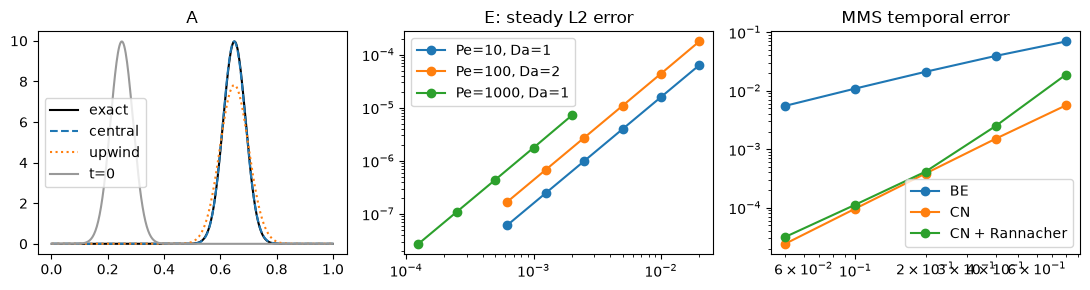

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].plot(profiles_A.x, profiles_A.exact, "k-", label="exact"); ax[0].plot(profiles_A.x, profiles_A.central, "--", label="central")
ax[0].plot(profiles_A.x, profiles_A.upwind, ":", label="upwind"); ax[0].plot(profiles_A.x, profiles_A.initial, color="0.6", label="t=0"); ax[0].legend(); ax[0].set_title("A")
for lab, d in convE.groupby("case"):
    ax[1].loglog(d.h, d.L2, "o-", label=lab)
ax[1].set_title("E: steady L2 error"); ax[1].legend()
for lab, d in mms_time.groupby("scheme"):
    ax[2].loglog(d.dt, d["L2 temporal"], "o-", label=lab)
ax[2].set_title("MMS temporal error"); ax[2].legend(); plt.tight_layout(); plt.show()

In [15]:
reporting.save_json(SUMMARY, "nb02_summary.json")
convA.to_csv(paths.TABLES / "convergence_benchA.csv", index=False)
convB.to_csv(paths.TABLES / "convergence_benchB.csv", index=False)
convC.to_csv(paths.TABLES / "convergence_benchC.csv", index=False)
convD.to_csv(paths.TABLES / "convergence_benchD.csv", index=False)
convE.to_csv(paths.TABLES / "convergence_benchE.csv", index=False)
print("saved nb02 summary and convergence tables")

saved nb02 summary and convergence tables
